In [1]:
from neo4j_utils import connect_to_neo4j, get_top_senders, get_frequent_pairs, get_mutual_transactions
from neo4j_utils import classify_wallet_tiers
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [2]:
graph = connect_to_neo4j()

top_senders = get_top_senders(graph)
print(top_senders)

def plot_top_senders(df):
    plt.figure(figsize=(8, 4))
    plt.bar(df["sender"], df["tx_count"], color="skyblue")
    plt.title("Top Senders by Transaction Count")
    plt.xlabel("Sender Address")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

      sender  tx_count
0   wallet_6        49
1   wallet_4        49
2   wallet_0        49
3   wallet_9        49
4  wallet_13        49


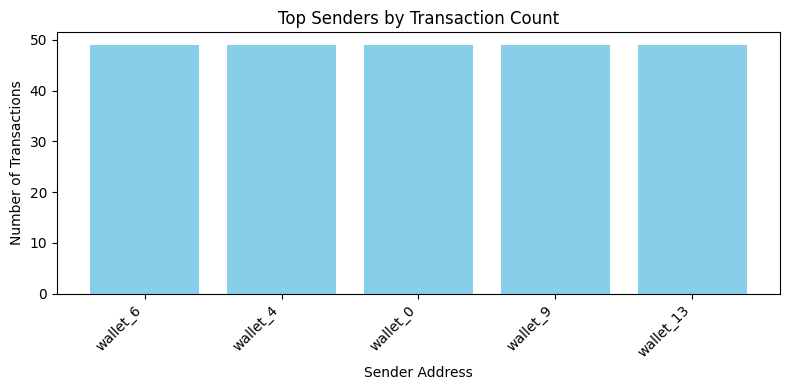

In [3]:
plot_top_senders(top_senders)

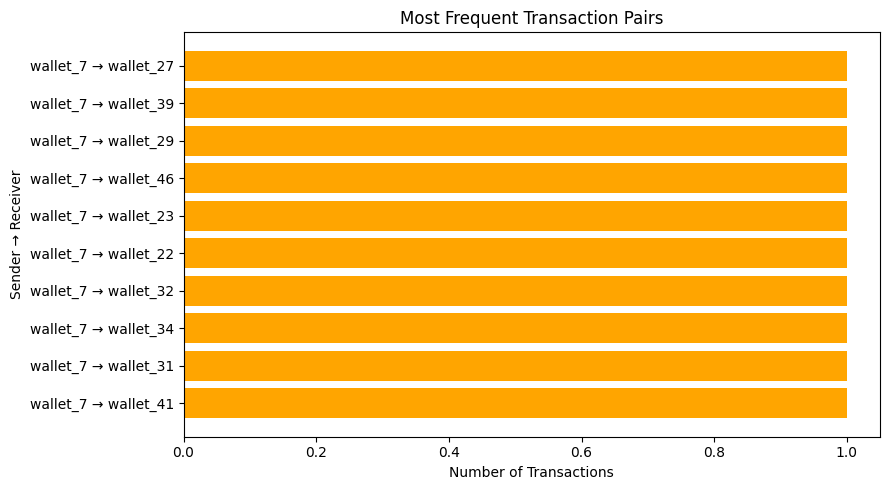

In [4]:
frequent_pairs = get_frequent_pairs(graph)

def plot_frequent_pairs(df):
    plt.figure(figsize=(9, 5))
    labels = [f"{s} → {r}" for s, r in zip(df["sender"], df["receiver"])]
    plt.barh(labels, df["tx_count"], color="orange")
    plt.title("Most Frequent Transaction Pairs")
    plt.xlabel("Number of Transactions")
    plt.ylabel("Sender → Receiver")
    plt.tight_layout()
    plt.show()

plot_frequent_pairs(frequent_pairs)

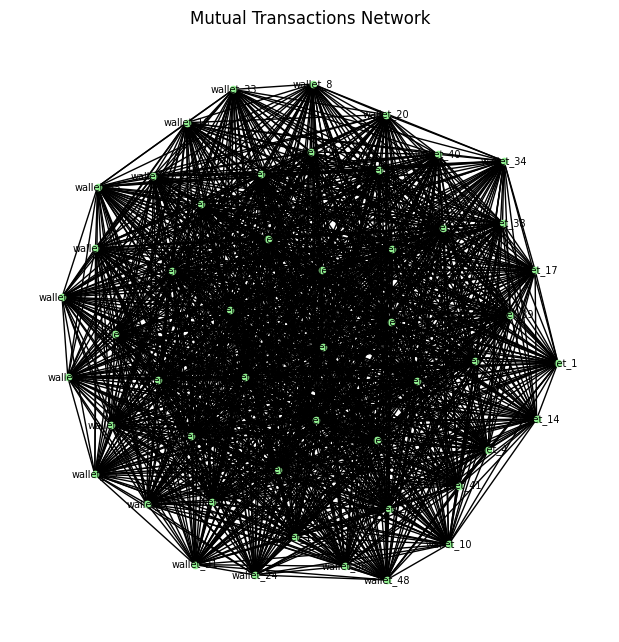

In [5]:
mutual_tx = get_mutual_transactions(graph)

def plot_mutual_transactions(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row["one"], row["two"])

    plt.figure(figsize=(6, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', node_size=20, font_size=7)
    plt.title("Mutual Transactions Network")
    plt.show()

plot_mutual_transactions(mutual_tx)

In [6]:
print(mutual_tx)

            one        two  tx_count
0      wallet_7  wallet_12         1
1      wallet_7  wallet_28         1
2      wallet_7  wallet_29         1
3      wallet_7  wallet_40         1
4      wallet_7  wallet_45         1
...         ...        ...       ...
2377  wallet_35  wallet_32         1
2378  wallet_35  wallet_15         1
2379  wallet_35  wallet_19         1
2380  wallet_35   wallet_4         1
2381  wallet_35  wallet_39         1

[2382 rows x 3 columns]


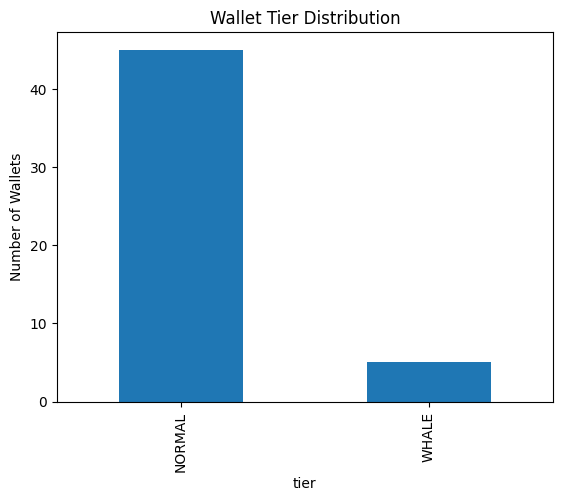

In [7]:
classify_wallet_tiers(graph)

df_tiers = graph.run("""
    MATCH (a:Address)
    RETURN a.tier AS tier, count(*) AS count
""").to_data_frame()

df_tiers.plot(kind="bar", x="tier", y="count", legend=False, title="Wallet Tier Distribution")
plt.ylabel("Number of Wallets")
plt.show()

Index(['time', 'price', 'volume'], dtype='object')
         time         price        volume
0  1739674838  97548.374421  1.394287e+10
1  1739674838  97548.374421  1.394287e+10
2  1739674838  97548.374421  1.394287e+10
3  1739674838  97548.374421  1.394287e+10
4  1739674838  97548.374421  1.394287e+10


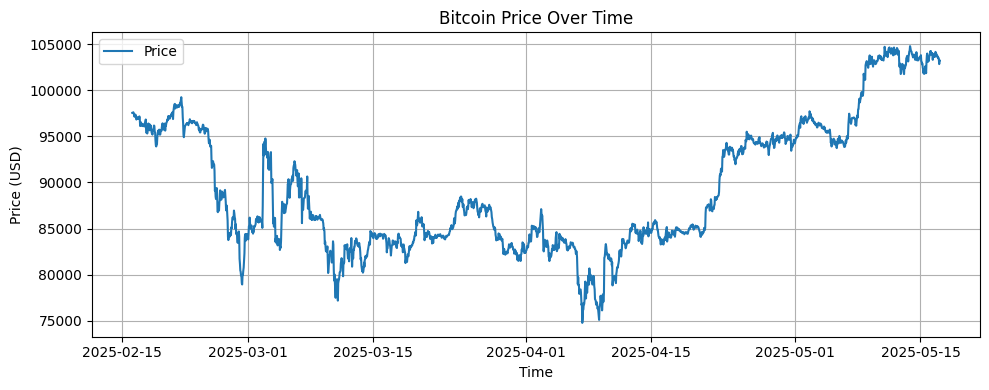

In [8]:
df_snapshots = graph.run("""
    MATCH (c:Coin)-[:HAS_SNAPSHOT]->(s:PriceSnapshot)
    WHERE c.id = 'bitcoin'
    RETURN s.timestamp AS time, s.price AS price, s.volume AS volume
    ORDER BY time
""").to_data_frame()

print(df_snapshots.columns)
print(df_snapshots.head())
# Convert to datetime
df_snapshots["time"] = pd.to_datetime(df_snapshots["time"], unit="s")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df_snapshots["time"], df_snapshots["price"], label="Price")
plt.title("Bitcoin Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()